## Wimbledon

We have 127 Wimbledon matches to test our model.

### input

model takes in these features in order:


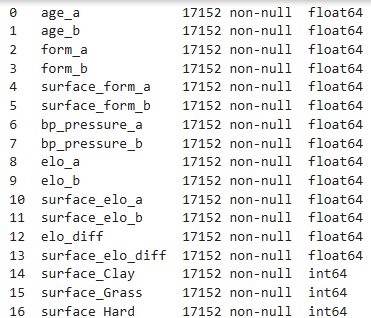


and will output a probability.

In [2]:
# data analytics + math
import pandas as pd 
import numpy as np 

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# other stuff used for later (need sci-kit learn too)
import xgboost # just installed it using !pip install

# set some parameters for pandas to view the data a bit better
pd.set_option('display.max_columns', 50) # see ALL columns
pd.set_option('display.width', 150)

# NOTE: this data is missing Sinner - Djokovic SF, and Sinner - Zverev F
df = pd.read_csv("../data/wimbledon.csv")

print(df.info())

# print(df.tail())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tourney_id          125 non-null    object 
 1   tourney_name        125 non-null    object 
 2   surface             125 non-null    object 
 3   draw_size           125 non-null    int64  
 4   tourney_level       125 non-null    object 
 5   indoor              125 non-null    object 
 6   tourney_date        125 non-null    int64  
 7   match_num           125 non-null    int64  
 8   winner_id           125 non-null    object 
 9   winner_seed         59 non-null     float64
 10  winner_entry        22 non-null     object 
 11  winner_name         125 non-null    object 
 12  winner_hand         125 non-null    object 
 13  winner_ht           125 non-null    int64  
 14  winner_ioc          125 non-null    object 
 15  winner_age          124 non-null    float64
 16  winner_r

### player stats

we have a trusty file called ```player_stats.csv``` that has all players and their most recent stats.

In [5]:
players = pd.read_csv("../data/player_stats.csv")

players.set_index('player', inplace=True)
# players.loc['Arthur Fery'] # this guy is gonna cause a problem...

### restructuring into model inputs

Basically, we want to use the Wimbledon data along with our ```player_stats.csv``` to have inputs for our model.

In [45]:
def restructure_wimbledon(df):
    df_a = pd.DataFrame({
        'player_a': df['winner_name'],
        'player_b': df['loser_name'],
        'label':    1
    })
    df_b = pd.DataFrame({
        'player_a': df['loser_name'],
        'player_b': df['winner_name'],
        'label':    0
    })
    return pd.concat([df_a, df_b], ignore_index=True)

wim = restructure_wimbledon(df)

# let's manually add Sinner Djokovic and Sinner Zverev (Sinner won both)
newRows = pd.DataFrame([
    {'player_a': "Jannik Sinner", "player_b": "Novak Djokovic", "label": 1},
    {'player_b': "Jannik Sinner", "player_a": "Novak Djokovic", "label": 0},
    {'player_a': "Jannik Sinner", "player_b": "Alexander Zverev", "label": 1},
    {'player_b': "Jannik Sinner", "player_a": "Alexander Zverev", "label": 0},
])
wim = pd.concat([wim, newRows], ignore_index=True)

wim

,player_a,player_b,label
0,Marton Fucsovics,Luca Van Assche,1
1,Rafael Jodar,Felix Gill,1
2,Jenson Brooksby,Aleksandar Vukic,1
3,Pablo Carreno Busta,Denis Shapovalov,1
4,Shintaro Mochizuki,Max Basing,1
...,...,...,...
249,Arthur Fery,Alexander Zverev,0
250,Jannik Sinner,Novak Djokovic,1
251,Novak Djokovic,Jannik Sinner,0
252,Jannik Sinner,Alexander Zverev,1


In [47]:
### iterating over the players + filling in the data
rows = []
for _, row in wim.iterrows():
    try:
        stats_a = players.loc[row['player_a']]
        stats_b = players.loc[row['player_b']]

        
        
        rows.append({
            'player_a':         row['player_a'],
            'player_b':         row['player_b'],
            'label':            row['label'],
            'age_a':            stats_a['age'],
            'age_b':            stats_b['age'],
            'form_a':           stats_a['recent_form'],
            'form_b':           stats_b['recent_form'],
            'surface_form_a':   stats_a['grass_form'],
            'surface_form_b':   stats_b['grass_form'],
            'bp_pressure_a':    stats_a['bp_pressure'],
            'bp_pressure_b':    stats_b['bp_pressure'],
            'elo_a':            stats_a['elo'],
            'elo_b':            stats_b['elo'],
            'surface_elo_a':    stats_a['grass_elo'],
            'surface_elo_b':    stats_b['grass_elo'],
            'elo_diff':         stats_a['elo'] - stats_b['elo'],
            'surface_elo_diff': stats_a['grass_elo'] - stats_b['grass_elo'],
            'surface_Clay':     0,
            'surface_Grass':    1, # because Wimbledon!
            'surface_Hard':     0,
        })
    except KeyError as e: # if we can't find a player, we don't add
        print(e)
data = pd.DataFrame(rows)

data

# note: there are 125 * 2 rows in total
# 127 originally but we skipped Max Basing and Felix Gill (both lost 1st round) so 125

'Felix Gill'
'Max Basing'
'Felix Gill'
'Max Basing'


,player_a,player_b,label,age_a,age_b,form_a,form_b,surface_form_a,surface_form_b,bp_pressure_a,bp_pressure_b,elo_a,elo_b,surface_elo_a,surface_elo_b,elo_diff,surface_elo_diff,surface_Clay,surface_Grass,surface_Hard
0,Marton Fucsovics,Luca Van Assche,1,34.352,22.048,0.3,0.6,0.500,0.333333,5.8,8.4,1596.362887,1613.754578,1642.324003,1451.221409,-17.391691,191.102594,0,1,0
1,Jenson Brooksby,Aleksandar Vukic,1,25.640,30.133,0.2,0.4,0.600,0.400000,7.3,6.3,1553.692582,1526.482512,1604.445790,1490.442291,27.210069,114.003499,0,1,0
2,Pablo Carreno Busta,Denis Shapovalov,1,34.886,27.173,0.5,0.3,0.400,0.500000,5.8,7.3,1714.520409,1585.497330,1488.350785,1509.862917,129.023079,-21.512132,0,1,0
3,Learner Tien,Dalibor Svrcina,1,20.539,23.595,0.8,0.6,0.625,0.500000,8.1,6.9,1884.832283,1615.089395,1560.090320,1500.000000,269.742888,60.090320,0,1,0
4,Tommy Paul,Alexandre Muller,1,29.095,29.311,0.8,0.3,0.800,0.333333,5.8,7.9,1919.627079,1509.908214,1743.860709,1491.179436,409.718866,252.681273,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,Arthur Fery,Alexander Zverev,0,23.937,29.166,0.5,1.0,0.500,0.700000,8.8,3.1,1571.870955,2146.503810,1510.185698,1758.056562,-574.632855,-247.870864,0,1,0
246,Jannik Sinner,Novak Djokovic,1,24.780,39.020,1.0,0.7,0.800,0.800000,2.1,8.6,2381.512589,2055.203766,1797.379041,2006.370483,326.308823,-208.991442,0,1,0
247,Novak Djokovic,Jannik Sinner,0,39.020,24.780,0.7,1.0,0.800,0.800000,8.6,2.1,2055.203766,2381.512589,2006.370483,1797.379041,-326.308823,208.991442,0,1,0
248,Jannik Sinner,Alexander Zverev,1,24.780,29.166,1.0,1.0,0.800,0.700000,2.1,3.1,2381.512589,2146.503810,1797.379041,1758.056562,235.008779,39.322479,0,1,0


### testing model

now we test our model saved as ```tennis_model_xgb.pkl```

In [48]:
import pickle
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score


model = pickle.load(open('../model/tennis_model_xgb_wimbledon.pkl', 'rb'))

# our features in this order
FEATURES = [
    'age_a', 'age_b',
    'form_a', 'form_b',
    'surface_form_a', 'surface_form_b',
    'bp_pressure_a', 'bp_pressure_b',
    'elo_a', 'elo_b',
    'surface_elo_a', 'surface_elo_b',
    'elo_diff', 'surface_elo_diff',
    'surface_Clay', 'surface_Grass', 'surface_Hard',
]



X = data[FEATURES] 
y = data['label']

y_pred = model.predict(X)
y_pred_proba = model.predict_proba(X)[:, 1]

accuracy = accuracy_score(y, y_pred)

# naive
naive = (data['elo_a'] > data['elo_b']).astype(int)
naive_accuracy = accuracy_score(y, naive)

print(f"Accuracy: {accuracy*100}")
print(f"Naive Accuracy: {naive_accuracy*100}")

Accuracy: 63.2
Naive Accuracy: 60.8


In [49]:
wim_features = data
    
wim_features['predicted_proba'] = y_pred_proba
wim_features['predicted_label'] = y_pred
wim_features['correct'] = (y_pred == y).astype(int)


# Matches the model got wrong
wrong = wim_features[wim_features['correct'] != 1][
    ['player_a', 'player_b', 'predicted_proba', 'label']
].sort_values('predicted_proba', ascending=False)

print(data[data['player_a'] == "Luciano Darderi"])

            player_a     player_b  label   age_a   age_b  form_a  form_b  surface_form_a  surface_form_b  bp_pressure_a  bp_pressure_b        elo_a  \
138  Luciano Darderi  Ethan Quinn      0  24.285  22.267     0.7     0.3            0.25        0.555556            6.0            5.6  1828.323646   

           elo_b  surface_elo_a  surface_elo_b    elo_diff  surface_elo_diff  surface_Clay  surface_Grass  surface_Hard  predicted_proba  \
138  1562.991542    1427.158274    1557.726989  265.332104       -130.568715             0              1             0         0.474757   

     predicted_label  correct  
138                0        1  


### other stuff

Sinner - Djokovic's SF match isn't recorded here. As is the same with Sinner - Zverev F match. It'll be much easier in the future, or if I am just curious about something, to make a function that simply takes in two names and outputs a probability prediction on who's going to win.

also like this, we can simulate a match between any two players!

In [50]:
def versus(player_a, player_b, surface='Hard'): # surface --> "Clay" or "Grass" or "Hard" (default is hard)
    try:
        stats_a = players.loc[player_a]
        stats_b = players.loc[player_b]
        
        info = pd.DataFrame([{
            'player_a':         row['player_a'],
            'player_b':         row['player_b'],
            'label':            row['label'],
            'age_a':            stats_a['age'],
            'age_b':            stats_b['age'],
            'form_a':           stats_a['recent_form'],
            'form_b':           stats_b['recent_form'],
            'surface_form_a':   stats_a['grass_form'],
            'surface_form_b':   stats_b['grass_form'],
            'bp_pressure_a':    stats_a['bp_pressure'],
            'bp_pressure_b':    stats_b['bp_pressure'],
            'elo_a':            stats_a['elo'],
            'elo_b':            stats_b['elo'],
            'surface_elo_a':    stats_a['grass_elo'],
            'surface_elo_b':    stats_b['grass_elo'],
            'elo_diff':         stats_a['elo'] - stats_b['elo'],
            'surface_elo_diff': stats_a['grass_elo'] - stats_b['grass_elo'],
            'surface_Clay':     1 if surface.lower() == 'clay' else 0,
            'surface_Grass':    1 if surface.lower() == 'grass' else 0,
            'surface_Hard':     1 if surface.lower() == 'hard' else 0,
        }])

        X = info[FEATURES]
    
        y_pred_proba = model.predict_proba(X)[:, 1][0]
    
        # print the winner and their probability
        print(f"{player_a} wins over {player_b}: {y_pred_proba*100}%" if y_pred_proba > 0.5 else f"{player_b} wins over {player_a}: {100-y_pred_proba*100}%")
        
    except KeyError as e:
        print(f"An error occured: {e}")



In [59]:
# 1v1 !
versus("Marton Fucsovics", "Luca Van Assche", 'Grass')

Marton Fucsovics wins over Luca Van Assche: 63.77177429199219%


### IBM SlamTracker

now admittedly, a 63.2% accuracy isn't the best and it beat the naive "pick the higher ranked guy" baseline only by 3%.

However, this Wimbledon had quite a lot of upsets and unpredictability, so it's not that surprising.

Wimbledon has IBM has a sponsor, and it sometimes has predictions for matches - they call it the IBM SlamTracker. Ultimately, I want to see what IBM ST predicted before every match and see how it compares to my model. However, cleanly getting that data, that pre-match prediction, is not that easy. There is no easy source or no simple CSV to retrieve. 

So, this is me going on the [Wimbledon website](https://www.wimbledon.com/en_GB/draws/gentlemens-singles) and manually checking all 127 matches to find out their pre-match prediction.

In [57]:
results = wim[wim['label'] == 1]

# this is every match, all 127, where player_a is the winner
results.to_csv("../ibm_prematch.csv", index=False)

#### done manually checking

after looking at pre match predictions 127 times, here's the result for IBM SlamTracker:

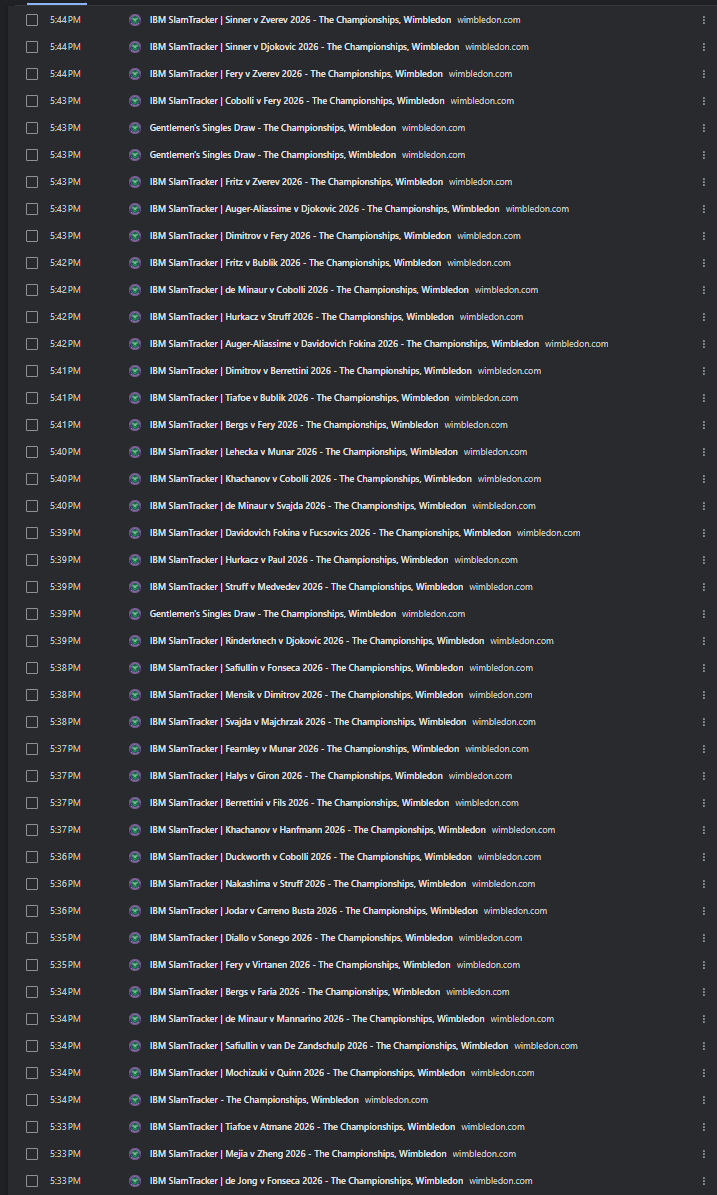

In [66]:
# modified ibm_prematch.csv directly
ibm = pd.read_csv('../ibm_prematch.csv')

# find accuracy
ibm_acc = float(ibm['label'].mean()) * 100
print(f"IBM SlamTracker accuracy: {ibm_acc}")

IBM SlamTracker accuracy: 63.77952755905512


### Conclusion

Dang it.

I got 63.2% and IBM ST got 63.7% - that's literally a difference of one prediction.

I couldn't beat IBM this time, but that was pretty damn close.